In [ ]:
import os
import shutil
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import zarr

from pyvcell.core.simdata.mesh import CartesianMesh
from pyvcell.core.simdata.postprocessing import PostProcessing
from pyvcell.core.simdata.simdata_models import PdeDataSet, DataFunctions
from pyvcell.core.simdata.zarr_writer import write_zarr
from pyvcell.core.solvers.fvsolver import solve as fvsolve

# Run a VCell PDE simulation from solver input files
1. Copy all files from solver_input directory to a temporary directory for solving
2. prepare empty solver output directory, copying in the functions file
2. Execute the Finite Volume PDE solver

In [2]:
# move all files from solver_input directory to a temporary directory for solving
temp_solver_dir = Path(tempfile.mkdtemp(prefix='pyvcell_test_data_'))
solver_input_dir = Path(os.getcwd()) / "solver_input"
for file in solver_input_dir.iterdir():
    print(file)
    shutil.copy(file, temp_solver_dir)

fv_input_file = temp_solver_dir / "SimID_946368938_0_.fvinput"
vcg_file = temp_solver_dir / "SimID_946368938_0_.vcg"
functions_file = temp_solver_dir / "SimID_946368938_0_.functions"

/Users/alexanderpatrie/Desktop/repos/pyvcell/examples/solver_input/TinySpatialProject_Application0.xml
/Users/alexanderpatrie/Desktop/repos/pyvcell/examples/solver_input/all.xml
/Users/alexanderpatrie/Desktop/repos/pyvcell/examples/solver_input/SimID_946368938_mathmodel.vcml
/Users/alexanderpatrie/Desktop/repos/pyvcell/examples/solver_input/all_edited.xml
/Users/alexanderpatrie/Desktop/repos/pyvcell/examples/solver_input/SimID_946368938_0_.mesh
/Users/alexanderpatrie/Desktop/repos/pyvcell/examples/solver_input/SimID_946368938_0__0.simtask.xml
/Users/alexanderpatrie/Desktop/repos/pyvcell/examples/solver_input/SimID_946368938_0_.fvinput
/Users/alexanderpatrie/Desktop/repos/pyvcell/examples/solver_input/SmallSpacialProject_3D.xml
/Users/alexanderpatrie/Desktop/repos/pyvcell/examples/solver_input/SimID_946368938_0_.meshmetrics
/Users/alexanderpatrie/Desktop/repos/pyvcell/examples/solver_input/SimID_946368938_0_.subdomains
/Users/alexanderpatrie/Desktop/repos/pyvcell/examples/solver_input/S

In [3]:
os.path.exists(solver_input_dir)

True

In [4]:
solver_output_dir = Path(os.getcwd()) / "test_output"

# clear contents of solver_output_dir
for file in solver_output_dir.iterdir():
    if file.is_file() and not file.name.startswith('.'):
        file.unlink()

# copy functions file to solver_output_dir
shutil.copy(functions_file, solver_output_dir)

# execute Finite Volume PDE solver
ret_code = fvsolve(input_file=fv_input_file, vcg_file=vcg_file, output_dir=solver_output_dir)
assert ret_code == 0

initializing mesh


Simulation Complete in Main() ... 


numVolume=126025

CartesianMesh::computeNormalsFromNeighbors(), compute normals from neighbors
Membrane Elements -> N=7817
--------Num of points that have zero neighbors 0
--------Num Neighbors before symmetrize 46161
--------Num Neighbors after symmetrize 51016
Total volume=5824.650822
Total FluxArea =36.79383373
Total FluxAreaXM =0
Total FluxAreaXP =0
Total FluxAreaYM =21.43445916
Total FluxAreaYP =15.35937457
Total FluxAreaZM =0
Total FluxAreaZP =0
mesh initialized
preprocessing finished
pdeCount=4, odeCount=0
error opening log file </Users/alexanderpatrie/Desktop/repos/pyvcell/examples/test_output/SimID_946368938_0_.log>
simulation [SimID_946368938_0_] started
temporary directory used is /var/folders/yy/8crj8x7x5_3b86f0js6_0bn00000gr/T/
sim file name is /var/folders/yy/8crj8x7x5_3b86f0js6_0bn00000gr/T/SimID_946368938_0_0000.sim
**This is a little endian machine.**
[[[data:0]]]
numVolRegions=6
Region 0: size=110800, offset=0
Region 1: size=12207, offset=110800
Region 2: size=1, offs

## extract the vcell simulation dataset from the tarball (compressed to save space)

## read vcell simulation results metadata
* `PdeDataSet` contains the metadata for the tabular simulation results (e.g. state variables, shape, time points)
* `DataFunctions` contains the function definitions (name, expression, type, domain)
![vcell simulation results](./example_vcell_ui.png)

In [5]:
sim_id = 946368938
job_id = 0
pde_dataset = PdeDataSet(base_dir=solver_output_dir, log_filename=f"SimID_{sim_id}_{job_id}_.log")
pde_dataset.read()
data_functions = DataFunctions(function_file=solver_output_dir / f"SimID_{sim_id}_{job_id}_.functions")
data_functions.read()
mesh = CartesianMesh(mesh_file=solver_output_dir / f"SimID_{sim_id}_{job_id}_.mesh")
mesh.read()
post_processing = PostProcessing(postprocessing_hdf5_path=solver_output_dir / f"SimID_{sim_id}_{job_id}_.hdf5")
post_processing.read()

## write the vcell simulation dataset to zarr including:
* metadata
* numerical datasets from stored data and evaluated functions
* ... masks for domains coming soon (e.g. cell, extracellular, etc.)

In [6]:
write_zarr(pde_dataset=pde_dataset, data_functions=data_functions, mesh=mesh, zarr_dir=solver_output_dir / "zarr")

## Open and display slices from the zarr dataset as an image
* no masking for domains
* different colormap and scaling

In [7]:
# Open the Zarr dataset
dataset = zarr.open(solver_output_dir / "zarr", mode='r')
metadata = dataset.attrs.asdict()['metadata']
display(f"shape = {dataset.shape}")
display(metadata)

'shape = (41, 10, 25, 71, 71)'

{'axes': [{'name': 't', 'type': 'time', 'unit': 'second'},
  {'name': 'c', 'type': 'channel', 'unit': None},
  {'name': 'z', 'type': 'space', 'unit': 'micrometer'},
  {'name': 'y', 'type': 'space', 'unit': 'micrometer'},
  {'name': 'x', 'type': 'space', 'unit': 'micrometer'}],
 'channels': [{'domain_name': 'all',
   'index': 0,
   'label': 'region_mask',
   'max_value': 5.0,
   'min_value': 0.0},
  {'domain_name': 'all',
   'index': 1,
   'label': 't',
   'max_value': 10.0,
   'min_value': 0.0},
  {'domain_name': 'all',
   'index': 2,
   'label': 'x',
   'max_value': 74.24,
   'min_value': 0.0},
  {'domain_name': 'all',
   'index': 3,
   'label': 'y',
   'max_value': 74.24,
   'min_value': 0.0},
  {'domain_name': 'all',
   'index': 4,
   'label': 'z',
   'max_value': 26.0,
   'min_value': 0.0},
  {'domain_name': 'cytosol',
   'index': 5,
   'label': 'C_cyt',
   'max_values': [0.0,
    1.6578610924672006e-05,
    3.6888106875105225e-05,
    5.83863912745076e-05,
    7.973301033949097e-0

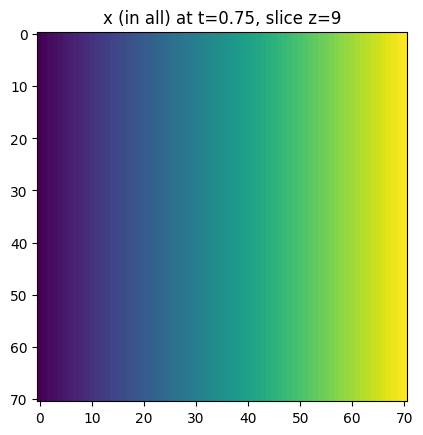

In [8]:
# Get a slice of the dataset, shape is (time, channel, z, y, x)
channel_index = 2
z_index = 9
time_index = 3
slice = dataset[time_index, channel_index, z_index, :, :]
channel_label = metadata['channels'][channel_index]['label']
channel_domain = metadata['channels'][channel_index]['domain_name']
t = metadata['times'][time_index]
title = f"{channel_label} (in {channel_domain}) at t={t}, slice z={z_index}"

# Display the slice as an image
plt.imshow(slice)
plt.title(title)
plt.show()

In [13]:
channels = metadata['channels']

channels[5].keys()

dict_keys(['domain_name', 'index', 'label', 'max_values', 'mean_values', 'min_values'])

In [9]:
channel_index = 2
time_index = 3
channel_domain = metadata['channels'][channel_index]['domain_name']
volume = dataset[time_index, channel_index, :, :, :]
mask = np.copy(dataset[3, 0, :, :, :])
z, y, x = np.where(mask == 1)

# Get the intensity values for these points
intensities = volume[z, y, x]

z

array([ 2,  2,  2, ..., 23, 23, 23])

In [10]:
mask

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

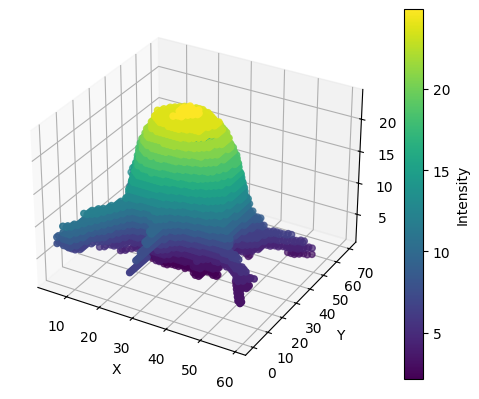

In [11]:
# Select a 3D volume for a single time point and channel, shape is (z, y, x)
channel_index = 2
time_index = 3
channel_domain = metadata['channels'][channel_index]['domain_name']
volume = dataset[time_index, channel_index, :, :, :]

# Create a figure for 3D plotting
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Define a mask to display the volume (use 'region_mask' channel)
mask = np.copy(dataset[3, 0, :, :, :])
z, y, x = np.where(mask == 1)

# Get the intensity values for these points
intensities = volume[z, y, x]

# Create a 3D scatter plot
scatter = ax.scatter(x, y, z, c=intensities, cmap='viridis')

# Add a color bar to represent intensities
fig.colorbar(scatter, ax=ax, label='Intensity')

# Set labels for axes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Show the plot
plt.show()

In [13]:
np.any(mask)

True

In [15]:
dir(mesh)

['__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'dimension',
 'extent',
 'get_membrane_region_ids',
 'get_membrane_region_index',
 'get_volume_domain_names',
 'get_volume_element_box',
 'get_volume_region_ids',
 'membrane_elements',
 'membrane_regions',
 'mesh_file',
 'origin',
 'read',
 'size',
 'volume_region_map',
 'volume_regions']

In [30]:
from pyvcell.core.simdata.simdata_models import DataBlockHeader, VariableType

volume_data_vars: list[DataBlockHeader] = [
        v.var_info.var_name for v in pde_dataset.variables_block_headers() if v.var_info.variable_type == VariableType.VOLUME
    ]




# get_var_names(pde_dataset)

volume_data_vars == get_var_names(pde_dataset)

True

In [11]:
t = metadata['times']
y = [c['mean_values'] for c in metadata['channels'] if c['index'] > 0]
y_labels = [c['label'] for c in metadata['channels'] if c['index'] > 0]

fig, ax = plt.subplots()
ax.plot(t, np.array(y).T.tolist())
ax.set(xlabel='time (s)', ylabel='concentration',
       title='Concentration over time')
ax.legend(y_labels)
ax.grid()


KeyError: 'mean_values'

## Open and display slices from the post processing dataset as an image

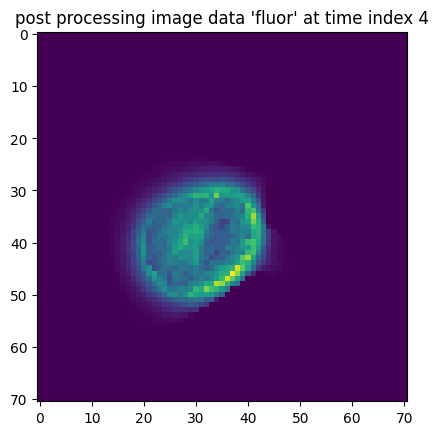

In [13]:
# display image dataset "fluor" at time index 4 as an image
fluorescence = post_processing.image_metadata[0]
image_data: np.ndarray = post_processing.read_image_data(image_metadata=fluorescence, time_index=4)
plt.imshow(image_data)
plt.title("post processing image data 'fluor' at time index 4")
plt.show()

## Open and display Variable Statistics from the post processing dataset

In [14]:
post_processing.variables[0].stat_var_unit

'uM'

list

pyvcell.simdata.postprocessing.VariableInfo

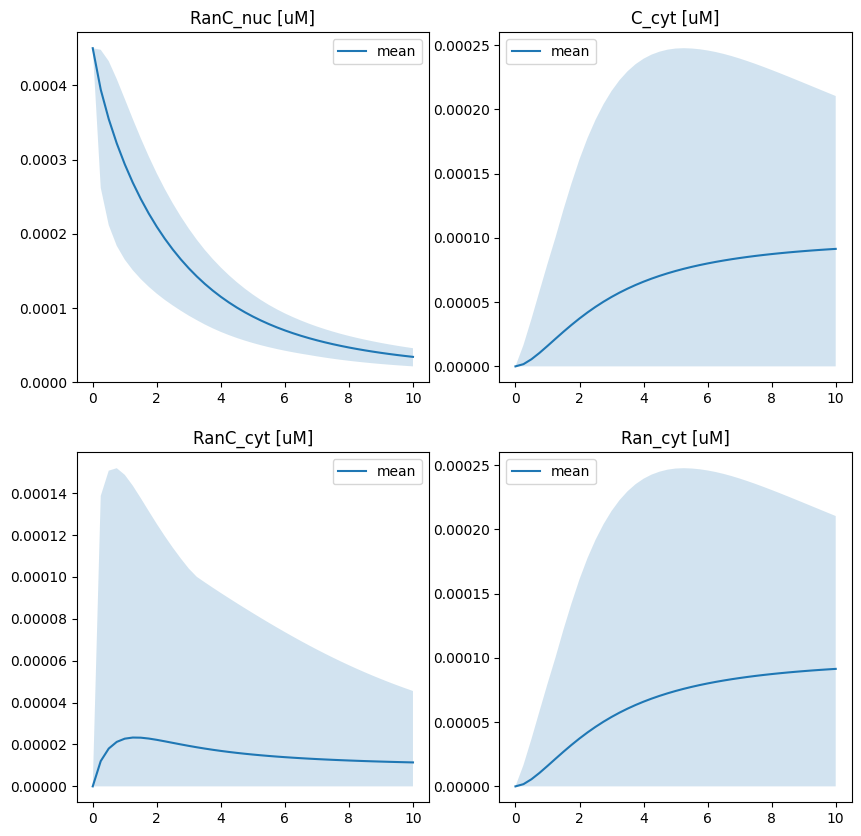

In [15]:
var_averages = list(set([var for var in post_processing.variables if var.statistic_type == 0]))
display(type(var_averages))
display(type(var_averages[0]))
series_arrays = []
series_legend = []
times = post_processing.times
# add envelope plot for each variable
for var_average in var_averages:
    series_arrays.append(post_processing.statistics[:,var_average.var_index,[0,2,3]])
    series_legend.append(f"{var_average.var_name} [{var_average.stat_var_unit}]")

# each series_array has 3 columns: mean, min, max
# plot each series on a different plot arranged in a 2x2 grid with a legend from series_legends
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
for i, series_array in enumerate(series_arrays):
    ax[int(i/2), i%2].plot(times, series_array[:,0], label='mean')
    ax[int(i/2), i%2].fill_between(times, series_array[:,1], series_array[:,2], alpha=0.2)
    ax[int(i/2), i%2].set_title(series_legend[i])
    ax[int(i/2), i%2].legend()